# How to classify a RGB drone dataset into vegetation types

## Preparation

This classifier program uses two datasets for it's analysis: 1) a 3-band RGB .tif file, and 2) a 1-band stratified canopy height model (CHM) stored in a .tif file. The most important preparatory step to using the classifier is to make sure that the naming, file organization and file format follow the logic required by the program. 

### Naming convention and file organization
The program assumes that your project has a basename, for example the name of the site the drone data was collected (e.g. day1_siteXY). The basename needs to be the name of the directory under which the two datasets are stored. The chm file is then expected to be stored in a subdirectory called *dem_and_derivatives*. The filename of both datasets needs to start with the project basename. Here is an example where day1_siteXY is the project basename:<br>
*file/to/datasets/day1_siteXY/*:<br>
- *day1_siteXY_hp_transparent_mosaic_group1.tif* <br>
- *dem_and_derivatives/day1_siteXY_hp_lp_chm_stratified.tif*

### File format

The program expects the RGB data to be stored in a 3-band .tif file and the canopy height data 1-band tif. The RGB .tif file is a standard output product of photogrammetry programs (such as Pix4D) where it is usually called orthomosaic. The canopy height is, to our knowledge, no standard output product of photogrammetry programs but needs to be calculated separately. Note that this repository also contains code and a tutorial to create a .tif file with a stratified canopy height model in the format required by the classifier (-> see xx tutorial for more information). 

The file structure expected by the classifier is shown in the figure below:

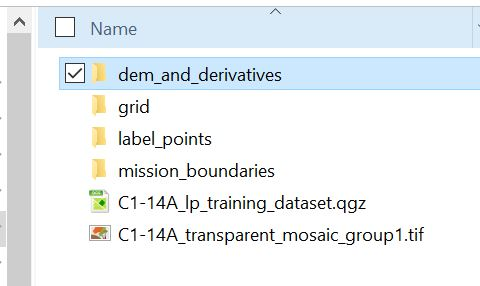

### Load packages

Now that the filenames, file formats and the file structure are in order, we can go ahead and load all the necessary packages. 

Note that if those packages are not installed in the environment that you are working in, you can remedie this either by manually installing the required packages, or by creating a new environment using the classification.yml file stored in this repository.

Here is what you need to do to create a new environment using the classification.yml file:
1. open the Anaconda prompt (in Windows you can go in the search bar and type *Anaconda prompt* and it should be listed if Anaconda is installed)
2. once the promt is open, it is necessary to navigate to the directory containing the classification.yml file. This can be done by typing *cd path/to/yml/file*
3. Then run the following command: *conda env create -n my-env -f classification.yml*<br>and replace *my-env* with the name you want to give to your new environment
4. Once the installation is finished, you can type *jupyter notebook* in the prompt and a tab will open in your browser. Navigate to the *How_to_classify_drone_dataset* notebook and you are ready to run the code below.

In [2]:
import pickle as pkl
import os
import rasterio as rio
import numpy as np
from classification_aux import classify_mission, load_site_data, feature_mission

### Load data

TO DO: Change the partly hardcoded paths in the classificatio.aux file and change the code block below accordingly

In [3]:
# rgb_dir = os.path.join('E:\TASR\qgis\day1_east_hp', 'day1_east_hp_transparent_mosaic_group1.tif').replace("\\", "/")
# chm_dir = os.path.join('E:\TASR\qgis\day1_east_hp\dem_and_derivatives', 'day1_east_hp_lp_chm_stratified.tif').replace("\\","/") 
# output_prefix = 'day1_east_hp'

site = 'day1_east_hp'
run_name = f'{site}_01'

# location of raw lichen data
data_dir = 'E:/TASR/qgis'

# place where chunked feature data is stored
run_dir = os.path.join('E:/TASR', 'classifier_runs', run_name)
#run_dir = f'C:/Users/MABEB16/science/postdoc/5_projects/1_general_classifier/4_general_classifier/runs/{run_name}'

if not os.path.exists(run_dir):
    os.makedirs(os.path.join(run_dir, 'composite'))

## Calculate features

In [7]:
rasters = load_site_data(data_dir, site)
chunks = 3

feature_mission(rasters, chunks, run_dir)

Writing chunk 0-0
Writing chunk 0-1
Writing chunk 0-2
Writing chunk 1-0
Writing chunk 1-1
Writing chunk 1-2
Writing chunk 2-0
Writing chunk 2-1
Writing chunk 2-2


## Choose classifier

In [ ]:
model_dir = 'C:/Users/MABEB16/science/postdoc/5_projects/1_general_classifier/4_general_classifier/results/2a_classifier/RF_is/'
with open(model_dir+f'RF_{site}.pkl', 'rb') as file:      
    model = pkl.load(file) 

## Classify drone data

In [ ]:
blocks = 8
rgb_file = os.path.join(data_dir, site, f'{site}_transparent_mosaic_group1.tif')
run_dir = f'C:/Users/MABEB16/science/postdoc/5_projects/1_general_classifier/4_general_classifier/runs/{run_name}'

output = classify_mission(blocks=blocks, rgb_file=rgb_file, run_dir=run_dir, model=model)

## Save result as .tiff

In [ ]:
out_file = 'C:/Users/MABEB16/science/postdoc/5_projects/1_general_classifier/4_general_classifier/results/classified/'

with rio.open(rgb_file) as f:
    meta = f.meta
meta.update(count=1)

# Write a new .tif file using the metadata from the original file
with rio.open(out_file, 'w', **meta) as dst:
    dst.write(output, 1)